In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, LabelEncoder

In [2]:
df = pd.read_csv("city_day.csv")

df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [3]:
print(df.shape)
df.info()

(29531, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [4]:
print("Missing Values\n")
print(df.isnull().sum())

Missing Values

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64


In [5]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].median()
)

print(df.isnull().sum())

City             0
Date             0
PM2.5            0
PM10             0
NO               0
NO2              0
NOx              0
NH3              0
CO               0
SO2              0
O3               0
Benzene          0
Toluene          0
Xylene           0
AQI              0
AQI_Bucket    4681
dtype: int64


In [6]:
print("Duplicate Rows :", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("After Removal :", df.shape)

Duplicate Rows : 0
After Removal : (29531, 16)


In [7]:
Q1 = df["AQI"].quantile(0.25)
Q3 = df["AQI"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["AQI"] < lower) |
              (df["AQI"] > upper)]

print(outliers.head())

         City        Date   PM2.5   PM10     NO    NO2    NOx    NH3     CO  \
29  Ahmedabad  2015-01-30   79.84  95.68  13.85  28.68  41.08  15.85  13.85   
30  Ahmedabad  2015-01-31   94.52  95.68  24.39  32.66  52.61  15.85  24.39   
31  Ahmedabad  2015-02-01  135.99  95.68  43.48  42.08  84.57  15.85  43.48   
32  Ahmedabad  2015-02-02  178.33  95.68  54.56  35.31  72.80  15.85  54.56   
33  Ahmedabad  2015-02-03  139.70  95.68  30.61  28.40  56.73  15.85  30.61   

      SO2      O3  Benzene  Toluene  Xylene    AQI AQI_Bucket  
29  48.49   97.07     0.04     0.00    4.81  328.0  Very Poor  
30  67.39  111.33     0.24     0.01    7.67  514.0     Severe  
31  75.23  102.70     0.40     0.04   25.87  782.0     Severe  
32  55.04  107.38     0.46     0.06   35.61  914.0     Severe  
33  33.79   73.60     0.17     0.03   11.87  660.0     Severe  


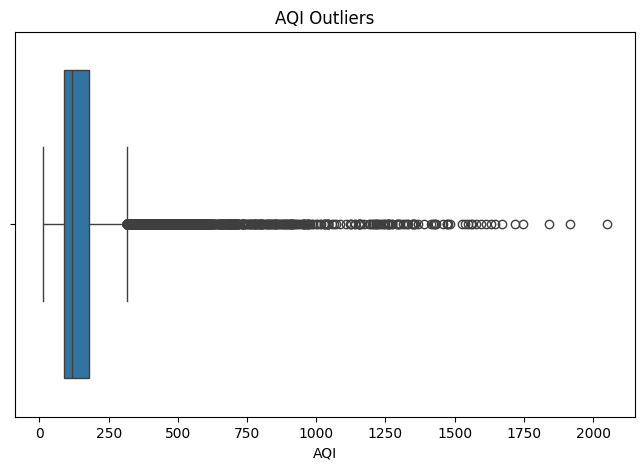

In [8]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["AQI"])

plt.title("AQI Outliers")

plt.show()

In [9]:
scaler = MinMaxScaler()

df[["AQI"]] = scaler.fit_transform(df[["AQI"]])

print(df[["AQI"]].head())

        AQI
0  0.051572
1  0.051572
2  0.051572
3  0.051572
4  0.051572


In [10]:
encoder = LabelEncoder()

df["AQI_Bucket"] = encoder.fit_transform(df["AQI_Bucket"])

print(df[["AQI_Bucket"]].head())

   AQI_Bucket
0           6
1           6
2           6
3           6
4           6


In [11]:
city = pd.get_dummies(df["City"])

print(city.head())

   Ahmedabad  Aizawl  Amaravati  Amritsar  Bengaluru  Bhopal  Brajrajnagar  \
0       True   False      False     False      False   False         False   
1       True   False      False     False      False   False         False   
2       True   False      False     False      False   False         False   
3       True   False      False     False      False   False         False   
4       True   False      False     False      False   False         False   

   Chandigarh  Chennai  Coimbatore  ...  Jorapokhar  Kochi  Kolkata  Lucknow  \
0       False    False       False  ...       False  False    False    False   
1       False    False       False  ...       False  False    False    False   
2       False    False       False  ...       False  False    False    False   
3       False    False       False  ...       False  False    False    False   
4       False    False       False  ...       False  False    False    False   

   Mumbai  Patna  Shillong  Talcher  Thiruvanantha

In [12]:
df.to_csv("cleaned_city_day.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
